ARTI308 - Machine Learning

# Lab 4: Data Quality Assessment & Preprocessing

In real-world machine learning projects, data is often:
- Incomplete (missing values)
- Noisy (outliers or random errors)
- Inconsistent (wrong formats, mixed units)

Before building any machine learning model, we must clean and prepare the data properly.

![step2.png](step2.png)

In this lab, we will apply practical preprocessing techniques step by step.

In [29]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

## 1. Load Dataset

In [30]:
pd.set_option("display.max_columns", None)

df = pd.read_csv("us_house_Sales_data.csv")
df.head(10)

,Price,Address,City,Zipcode,State,Bedrooms,Bathrooms,Area (Sqft),Lot Size,Year Built,Days on Market,Property Type,MLS ID,Listing Agent,Status,Listing URL
0,"$554,217","5926 Oak Ave, San Diego, CA 65383",San Diego,65383,CA,1 bds,3 ba,772 sqft,4757 sqft,1959,101,Townhouse,Z104635,Alex Johnson - Compass,For Sale,https://www.zillow.com/homedetails/80374762_zpid/
1,"$164,454","9583 Oak Ave, Fresno, IL 79339",Fresno,79339,IL,1 bds,1 ba,2348 sqft,3615 sqft,1969,46,Apartment,Z535721,Emily Davis - Century 21,Sold,https://www.zillow.com/homedetails/86143665_zpid/
2,"$1,249,331","8224 Oak Ave, Sacramento, TX 87393",Sacramento,87393,TX,6 bds,1 ba,3630 sqft,9369 sqft,1990,59,Townhouse,Z900458,Mike Lee - Coldwell Banker,For Sale,https://www.zillow.com/homedetails/37082403_zpid/
3,"$189,267","232 Oak Ave, Fresno, TX 38666",Fresno,38666,TX,2 bds,1 ba,605 sqft,8804 sqft,1958,119,Apartment,Z318589,John Doe - RE/MAX,Pending,https://www.zillow.com/homedetails/39318132_zpid/
4,"$465,778","5446 Pine Rd, Los Angeles, CA 23989",Los Angeles,23989,CA,3 bds,2 ba,1711 sqft,9260 sqft,2020,26,Townhouse,Z899716,John Doe - RE/MAX,Pending,https://www.zillow.com/homedetails/22454634_zpid/
5,"$738,357","9202 Maple Dr, Sacramento, NY 71318",Sacramento,71318,NY,5 bds,3 ba,1177 sqft,8317 sqft,2015,35,Multi-Family,Z865468,Jane Smith - Keller Williams,Pending,https://www.zillow.com/homedetails/90690049_zpid/
6,"$1,325,395","2698 Elm St, Sacramento, NY 57421",Sacramento,57421,NY,6 bds,1 ba,1990 sqft,5592 sqft,2012,94,Townhouse,Z689873,Alex Johnson - Compass,Pending,https://www.zillow.com/homedetails/99288749_zpid/
7,"$1,158,003","2118 Main St, San Diego, IL 64361",San Diego,64361,IL,2 bds,2 ba,1008 sqft,6010 sqft,1975,75,Townhouse,Z329631,John Doe - RE/MAX,For Sale,https://www.zillow.com/homedetails/91922548_zpid/
8,"$240,095","9474 Main St, San Francisco, FL 13227",San Francisco,13227,FL,6 bds,2 ba,929 sqft,5449 sqft,1975,79,Townhouse,Z839936,John Doe - RE/MAX,Pending,https://www.zillow.com/homedetails/79694016_zpid/
9,"$1,356,448","8803 Maple Dr, San Diego, NY 57397",San Diego,57397,NY,2 bds,3 ba,2094 sqft,2179 sqft,1970,111,Multi-Family,Z264011,John Doe - RE/MAX,Pending,https://www.zillow.com/homedetails/13312383_zpid/


## 2. Data Quality Assessment
### 2.1 Check Data Types
Data types must match the real meaning of each column.
For example:
- `Price` should be numeric
- `Area (Sqft)` should be numeric
- `Year Built` should be integer

In [31]:
df.dtypes

Price               str
Address             str
City                str
Zipcode           int64
State               str
Bedrooms            str
Bathrooms           str
Area (Sqft)         str
Lot Size            str
Year Built        int64
Days on Market    int64
Property Type       str
MLS ID              str
Listing Agent       str
Status              str
Listing URL         str
dtype: object

We observe that some columns are stored as object type.
`Price`, `Area (Sqft)`, `Bedrooms`, and `Bathrooms` may not yet be in the correct format.
Incorrect data types can prevent proper calculations and analysis.

### 2.2 Convert Incorrect Data Types
We will convert:
- `Price` to numeric after removing currency symbols
- `Area (Sqft)` and `Lot Size` to numeric after removing text units
- `Bedrooms` and `Bathrooms` to numeric values

In [32]:
df['Price'] = df['Price'].replace(r'[\$,]', '', regex=True)
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

df['Area (Sqft)'] = df['Area (Sqft)'].replace(r'[^0-9.]', '', regex=True)
df['Area (Sqft)'] = pd.to_numeric(df['Area (Sqft)'], errors='coerce')

df['Bedrooms'] = pd.to_numeric(df['Bedrooms'].astype(str).str.extract(r'(\d+)')[0], errors='coerce')
df['Bathrooms'] = pd.to_numeric(df['Bathrooms'].astype(str).str.extract(r'(\d+)')[0], errors='coerce')

df['Lot Size'] = df['Lot Size'].replace(r'[^0-9.]', '', regex=True)
df['Lot Size'] = pd.to_numeric(df['Lot Size'], errors='coerce')

df.dtypes

Price             int64
Address             str
City                str
Zipcode           int64
State               str
Bedrooms          int64
Bathrooms         int64
Area (Sqft)       int64
Lot Size          int64
Year Built        int64
Days on Market    int64
Property Type       str
MLS ID              str
Listing Agent       str
Status              str
Listing URL         str
dtype: object

Now `Price` and `Area (Sqft)` are correctly stored as numeric values.
`Bedrooms`, `Bathrooms`, and `Lot Size` are also converted to usable numeric formats.
This allows us to perform calculations and preprocessing correctly.

## 3. Handling Missing Values
### 3.1 Detect Missing Values
Missing values reduce data quality and can affect model performance.

In [33]:
df.isna().sum()

Price             0
Address           0
City              0
Zipcode           0
State             0
Bedrooms          0
Bathrooms         0
Area (Sqft)       0
Lot Size          0
Year Built        0
Days on Market    0
Property Type     0
MLS ID            0
Listing Agent     0
Status            0
Listing URL       0
dtype: int64

The output shows whether any column contains missing values.
If all values are zero, the dataset is complete.
If any column contains missing values, we must handle them.

### 3.2 Demonstration: Introduce Artificial Missing Values
### Why?

Since this dataset has no missing values, we introduce artificial ones *for learning purposes*.

We run this line:

`df_missing.loc[0:5, 'Price'] = np.nan`

- `df_missing`: the DataFrame being modified.
- `.loc[0:5, 'Price']`: selects rows 0 to 5 in the `Price` column.
- `= np.nan`: assigns missing values (Not a Number) to those cells.

In [55]:
df_missing = df.copy()
df_missing.loc[0:5, 'Price'] = np.nan
df_missing.isna().sum()

Price             6
Address           0
City              0
Zipcode           0
State             0
Bedrooms          0
Bathrooms         0
Area (Sqft)       0
Lot Size          0
Year Built        0
Days on Market    0
Property Type     0
MLS ID            0
Listing Agent     0
Status            0
Listing URL       0
dtype: int64

Now the `Price` column contains missing values.

In [56]:
print("Original shape: ",df.shape)
print("After removing some values: ",df_missing.shape)

Original shape:  (3000, 16)
After removing some values:  (3000, 16)


In [57]:
df_missing.head(10)

,Price,Address,City,Zipcode,State,Bedrooms,Bathrooms,Area (Sqft),Lot Size,Year Built,Days on Market,Property Type,MLS ID,Listing Agent,Status,Listing URL
0,NaN,"5926 Oak Ave, San Diego, CA 65383",San Diego,65383,CA,1,3,772,4757,1959,101,Townhouse,Z104635,Alex Johnson - Compass,For Sale,https://www.zillow.com/homedetails/80374762_zpid/
1,NaN,"9583 Oak Ave, Fresno, IL 79339",Fresno,79339,IL,1,1,2348,3615,1969,46,Apartment,Z535721,Emily Davis - Century 21,Sold,https://www.zillow.com/homedetails/86143665_zpid/
2,NaN,"8224 Oak Ave, Sacramento, TX 87393",Sacramento,87393,TX,6,1,3630,9369,1990,59,Townhouse,Z900458,Mike Lee - Coldwell Banker,For Sale,https://www.zillow.com/homedetails/37082403_zpid/
3,NaN,"232 Oak Ave, Fresno, TX 38666",Fresno,38666,TX,2,1,605,8804,1958,119,Apartment,Z318589,John Doe - RE/MAX,Pending,https://www.zillow.com/homedetails/39318132_zpid/
4,NaN,"5446 Pine Rd, Los Angeles, CA 23989",Los Angeles,23989,CA,3,2,1711,9260,2020,26,Townhouse,Z899716,John Doe - RE/MAX,Pending,https://www.zillow.com/homedetails/22454634_zpid/
5,NaN,"9202 Maple Dr, Sacramento, NY 71318",Sacramento,71318,NY,5,3,1177,8317,2015,35,Multi-Family,Z865468,Jane Smith - Keller Williams,Pending,https://www.zillow.com/homedetails/90690049_zpid/
6,1325395.0,"2698 Elm St, Sacramento, NY 57421",Sacramento,57421,NY,6,1,1990,5592,2012,94,Townhouse,Z689873,Alex Johnson - Compass,Pending,https://www.zillow.com/homedetails/99288749_zpid/
7,1158003.0,"2118 Main St, San Diego, IL 64361",San Diego,64361,IL,2,2,1008,6010,1975,75,Townhouse,Z329631,John Doe - RE/MAX,For Sale,https://www.zillow.com/homedetails/91922548_zpid/
8,240095.0,"9474 Main St, San Francisco, FL 13227",San Francisco,13227,FL,6,2,929,5449,1975,79,Townhouse,Z839936,John Doe - RE/MAX,Pending,https://www.zillow.com/homedetails/79694016_zpid/
9,1356448.0,"8803 Maple Dr, San Diego, NY 57397",San Diego,57397,NY,2,3,2094,2179,1970,111,Multi-Family,Z264011,John Doe - RE/MAX,Pending,https://www.zillow.com/homedetails/13312383_zpid/


### Strategy 1: Remove Records
This strategy removes records containing missing data.
It works well if the number of missing rows is small.

In [58]:
df_removed = df_missing.dropna()
df_removed.shape

(2994, 16)

In [59]:
df_removed.isna().sum()

Price             0
Address           0
City              0
Zipcode           0
State             0
Bedrooms          0
Bathrooms         0
Area (Sqft)       0
Lot Size          0
Year Built        0
Days on Market    0
Property Type     0
MLS ID            0
Listing Agent     0
Status            0
Listing URL       0
dtype: int64

The dataset now has fewer rows.
If only a small portion of data was missing, this method is acceptable.

However, removing too many rows can reduce model performance.

### Strategy 2: Mean Imputation

![Mean.png](Mean.png)

The mean represents the average value.
It is commonly used for normally distributed data.

In [60]:
df_missing.head(10)

,Price,Address,City,Zipcode,State,Bedrooms,Bathrooms,Area (Sqft),Lot Size,Year Built,Days on Market,Property Type,MLS ID,Listing Agent,Status,Listing URL
0,NaN,"5926 Oak Ave, San Diego, CA 65383",San Diego,65383,CA,1,3,772,4757,1959,101,Townhouse,Z104635,Alex Johnson - Compass,For Sale,https://www.zillow.com/homedetails/80374762_zpid/
1,NaN,"9583 Oak Ave, Fresno, IL 79339",Fresno,79339,IL,1,1,2348,3615,1969,46,Apartment,Z535721,Emily Davis - Century 21,Sold,https://www.zillow.com/homedetails/86143665_zpid/
2,NaN,"8224 Oak Ave, Sacramento, TX 87393",Sacramento,87393,TX,6,1,3630,9369,1990,59,Townhouse,Z900458,Mike Lee - Coldwell Banker,For Sale,https://www.zillow.com/homedetails/37082403_zpid/
3,NaN,"232 Oak Ave, Fresno, TX 38666",Fresno,38666,TX,2,1,605,8804,1958,119,Apartment,Z318589,John Doe - RE/MAX,Pending,https://www.zillow.com/homedetails/39318132_zpid/
4,NaN,"5446 Pine Rd, Los Angeles, CA 23989",Los Angeles,23989,CA,3,2,1711,9260,2020,26,Townhouse,Z899716,John Doe - RE/MAX,Pending,https://www.zillow.com/homedetails/22454634_zpid/
5,NaN,"9202 Maple Dr, Sacramento, NY 71318",Sacramento,71318,NY,5,3,1177,8317,2015,35,Multi-Family,Z865468,Jane Smith - Keller Williams,Pending,https://www.zillow.com/homedetails/90690049_zpid/
6,1325395.0,"2698 Elm St, Sacramento, NY 57421",Sacramento,57421,NY,6,1,1990,5592,2012,94,Townhouse,Z689873,Alex Johnson - Compass,Pending,https://www.zillow.com/homedetails/99288749_zpid/
7,1158003.0,"2118 Main St, San Diego, IL 64361",San Diego,64361,IL,2,2,1008,6010,1975,75,Townhouse,Z329631,John Doe - RE/MAX,For Sale,https://www.zillow.com/homedetails/91922548_zpid/
8,240095.0,"9474 Main St, San Francisco, FL 13227",San Francisco,13227,FL,6,2,929,5449,1975,79,Townhouse,Z839936,John Doe - RE/MAX,Pending,https://www.zillow.com/homedetails/79694016_zpid/
9,1356448.0,"8803 Maple Dr, San Diego, NY 57397",San Diego,57397,NY,2,3,2094,2179,1970,111,Multi-Family,Z264011,John Doe - RE/MAX,Pending,https://www.zillow.com/homedetails/13312383_zpid/


In [61]:
df_imputed_mean = df_missing.copy()
df_imputed_mean['Price'] = df_imputed_mean['Price'].fillna(df_imputed_mean['Price'].mean())

df_imputed_mean.isna().sum()

Price             0
Address           0
City              0
Zipcode           0
State             0
Bedrooms          0
Bathrooms         0
Area (Sqft)       0
Lot Size          0
Year Built        0
Days on Market    0
Property Type     0
MLS ID            0
Listing Agent     0
Status            0
Listing URL       0
dtype: int64

In [62]:
df_imputed_mean.head(10)

,Price,Address,City,Zipcode,State,Bedrooms,Bathrooms,Area (Sqft),Lot Size,Year Built,Days on Market,Property Type,MLS ID,Listing Agent,Status,Listing URL
0,8.113616e+05,"5926 Oak Ave, San Diego, CA 65383",San Diego,65383,CA,1,3,772,4757,1959,101,Townhouse,Z104635,Alex Johnson - Compass,For Sale,https://www.zillow.com/homedetails/80374762_zpid/
1,8.113616e+05,"9583 Oak Ave, Fresno, IL 79339",Fresno,79339,IL,1,1,2348,3615,1969,46,Apartment,Z535721,Emily Davis - Century 21,Sold,https://www.zillow.com/homedetails/86143665_zpid/
2,8.113616e+05,"8224 Oak Ave, Sacramento, TX 87393",Sacramento,87393,TX,6,1,3630,9369,1990,59,Townhouse,Z900458,Mike Lee - Coldwell Banker,For Sale,https://www.zillow.com/homedetails/37082403_zpid/
3,8.113616e+05,"232 Oak Ave, Fresno, TX 38666",Fresno,38666,TX,2,1,605,8804,1958,119,Apartment,Z318589,John Doe - RE/MAX,Pending,https://www.zillow.com/homedetails/39318132_zpid/
4,8.113616e+05,"5446 Pine Rd, Los Angeles, CA 23989",Los Angeles,23989,CA,3,2,1711,9260,2020,26,Townhouse,Z899716,John Doe - RE/MAX,Pending,https://www.zillow.com/homedetails/22454634_zpid/
5,8.113616e+05,"9202 Maple Dr, Sacramento, NY 71318",Sacramento,71318,NY,5,3,1177,8317,2015,35,Multi-Family,Z865468,Jane Smith - Keller Williams,Pending,https://www.zillow.com/homedetails/90690049_zpid/
6,1.325395e+06,"2698 Elm St, Sacramento, NY 57421",Sacramento,57421,NY,6,1,1990,5592,2012,94,Townhouse,Z689873,Alex Johnson - Compass,Pending,https://www.zillow.com/homedetails/99288749_zpid/
7,1.158003e+06,"2118 Main St, San Diego, IL 64361",San Diego,64361,IL,2,2,1008,6010,1975,75,Townhouse,Z329631,John Doe - RE/MAX,For Sale,https://www.zillow.com/homedetails/91922548_zpid/
8,2.400950e+05,"9474 Main St, San Francisco, FL 13227",San Francisco,13227,FL,6,2,929,5449,1975,79,Townhouse,Z839936,John Doe - RE/MAX,Pending,https://www.zillow.com/homedetails/79694016_zpid/
9,1.356448e+06,"8803 Maple Dr, San Diego, NY 57397",San Diego,57397,NY,2,3,2094,2179,1970,111,Multi-Family,Z264011,John Doe - RE/MAX,Pending,https://www.zillow.com/homedetails/13312383_zpid/


Missing values are now replaced with the average house price.
This preserves dataset size but may reduce variability.
Mean imputation is sensitive to outliers.

### Strategy 3: Median Imputation

![median_formula_2.png](median_formula_2.png)
The median is more robust to outliers than the mean.
It is preferred for skewed data.

In [63]:
df_imputed_median = df_missing.copy()
df_imputed_median['Price'] = df_imputed_median['Price'].fillna(df_imputed_median['Price'].median())

df_imputed_median.isna().sum()

Price             0
Address           0
City              0
Zipcode           0
State             0
Bedrooms          0
Bathrooms         0
Area (Sqft)       0
Lot Size          0
Year Built        0
Days on Market    0
Property Type     0
MLS ID            0
Listing Agent     0
Status            0
Listing URL       0
dtype: int64

In [43]:
df_imputed_median.head(10)

,Price,Address,City,Zipcode,State,Bedrooms,Bathrooms,Area (Sqft),Lot Size,Year Built,Days on Market,Property Type,MLS ID,Listing Agent,Status,Listing URL
0,816203.0,"5926 Oak Ave, San Diego, CA 65383",San Diego,65383,CA,1,3,772,4757,1959,101,Townhouse,Z104635,Alex Johnson - Compass,For Sale,https://www.zillow.com/homedetails/80374762_zpid/
1,816203.0,"9583 Oak Ave, Fresno, IL 79339",Fresno,79339,IL,1,1,2348,3615,1969,46,Apartment,Z535721,Emily Davis - Century 21,Sold,https://www.zillow.com/homedetails/86143665_zpid/
2,816203.0,"8224 Oak Ave, Sacramento, TX 87393",Sacramento,87393,TX,6,1,3630,9369,1990,59,Townhouse,Z900458,Mike Lee - Coldwell Banker,For Sale,https://www.zillow.com/homedetails/37082403_zpid/
3,816203.0,"232 Oak Ave, Fresno, TX 38666",Fresno,38666,TX,2,1,605,8804,1958,119,Apartment,Z318589,John Doe - RE/MAX,Pending,https://www.zillow.com/homedetails/39318132_zpid/
4,816203.0,"5446 Pine Rd, Los Angeles, CA 23989",Los Angeles,23989,CA,3,2,1711,9260,2020,26,Townhouse,Z899716,John Doe - RE/MAX,Pending,https://www.zillow.com/homedetails/22454634_zpid/
5,816203.0,"9202 Maple Dr, Sacramento, NY 71318",Sacramento,71318,NY,5,3,1177,8317,2015,35,Multi-Family,Z865468,Jane Smith - Keller Williams,Pending,https://www.zillow.com/homedetails/90690049_zpid/
6,1325395.0,"2698 Elm St, Sacramento, NY 57421",Sacramento,57421,NY,6,1,1990,5592,2012,94,Townhouse,Z689873,Alex Johnson - Compass,Pending,https://www.zillow.com/homedetails/99288749_zpid/
7,1158003.0,"2118 Main St, San Diego, IL 64361",San Diego,64361,IL,2,2,1008,6010,1975,75,Townhouse,Z329631,John Doe - RE/MAX,For Sale,https://www.zillow.com/homedetails/91922548_zpid/
8,240095.0,"9474 Main St, San Francisco, FL 13227",San Francisco,13227,FL,6,2,929,5449,1975,79,Townhouse,Z839936,John Doe - RE/MAX,Pending,https://www.zillow.com/homedetails/79694016_zpid/
9,1356448.0,"8803 Maple Dr, San Diego, NY 57397",San Diego,57397,NY,2,3,2094,2179,1970,111,Multi-Family,Z264011,John Doe - RE/MAX,Pending,https://www.zillow.com/homedetails/13312383_zpid/


Missing values are replaced with the middle value.
This approach is safer when data contains extreme values.

## 4. Handling Outliers
Outliers are extreme values that can distort models.
We will detect outliers using IQR method.

![IQR.png](IQR.png)

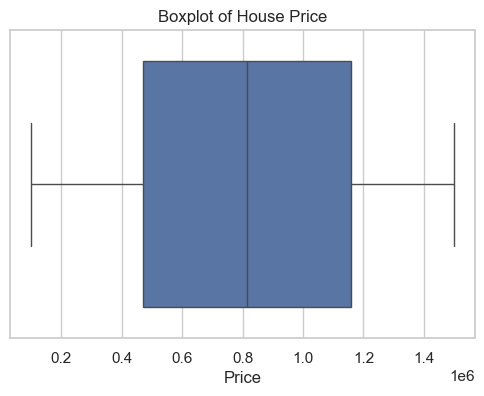

In [64]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Price'])
plt.title("Boxplot of House Price")
plt.show()

Points outside the whiskers represent potential outliers.
These extreme house prices may influence model behavior.

### Detect Outliers using IQR
**Method: Interquartile Range (IQR)**

The IQR method defines outliers as values outside:

`Q1 - 1.5×IQR`  and  `Q3 + 1.5×IQR`

In [66]:
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Price'] < lower) | (df['Price'] > upper)]
outliers.head(15)

,Price,Address,City,Zipcode,State,Bedrooms,Bathrooms,Area (Sqft),Lot Size,Year Built,Days on Market,Property Type,MLS ID,Listing Agent,Status,Listing URL


The output displays records considered extreme based on statistical boundaries.
These may be valid high-value property listings or potential data errors.

### Remove Outliers
We remove values outside the acceptable range.

In [67]:
df_no_outliers = df[(df['Price'] >= lower) & (df['Price'] <= upper)]
print("Original shape: ",df.shape)
print("After removing outliers: ",df_no_outliers.shape)

Original shape:  (3000, 16)
After removing outliers:  (3000, 16)


The dataset size is slightly reduced.
Removing outliers reduces distortion but may also remove important rare events.

#### Important Note on Removing Outliers

Not all outliers are errors.

Some extreme values may represent rare but important real-world cases.
For example, in housing data, a very high price may reflect a luxury property in a premium location.

If we remove such values blindly, we may lose valuable information and bias the analysis.

Before removing outliers, we should always ask:
- Is this value a data entry mistake?
- Or is it a valid but rare observation?

### Capping Outliers (Percentile Method)
Instead of removing outliers, we replace extreme values with percentile limits.

![percentile.png](percentile.png)

In [68]:
lower_cap = df['Price'].quantile(0.05)
upper_cap = df['Price'].quantile(0.95)

df_capped = df.copy()
df_capped['Price'] = df_capped['Price'].clip(lower_cap, upper_cap)

## 5. Data Transformation – Normalization
Normalization scales numerical features to a similar range.
This ensures that no feature influences the model simply because it has larger numerical values.

### Min-Max Normalization
Min-Max normalization rescales numerical values to a fixed range, usually between 0 and 1.

It works using the formula:
![min_max.png](min_max.png)

This method preserves the original distribution shape and relative ordering of values.

Min-Max normalization is especially useful for distance-based models such as:
- K-Nearest Neighbors (KNN)
- K-Means clustering
- Support Vector Machines (SVM)

These models rely on distance calculations, and if features are on very different scales, one feature can dominate the distance computation.

In [69]:
df[['Price', 'Area (Sqft)']].head()

,Price,Area (Sqft)
0,554217,772
1,164454,2348
2,1249331,3630
3,189267,605
4,465778,1711


In [70]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_scaled = df[['Price', 'Area (Sqft)']].copy()

df_scaled[['Price', 'Area (Sqft)']] = scaler.fit_transform(df_scaled)

df_scaled.head()

,Price,Area (Sqft)
0,0.324426,0.050603
1,0.045863,0.514269
2,0.821224,0.891439
3,0.063597,0.001471
4,0.261219,0.326861


After applying Min-Max normalization, all numerical values are scaled to the range between 0 and 1.

The smallest value in each feature becomes 0, and the largest becomes 1.
All other values are proportionally mapped between these two limits.

Importantly, normalization does NOT change the relative relationships between data points.
If one property originally had a higher price than another, it will still have a higher normalized value.

### Z-Score Normalization
Z-score standardization transforms the data so that:

- The mean of each feature becomes 0
- The standard deviation becomes 1

This is done by subtracting the mean and dividing by the standard deviation:

![zscore.png](zscore.png)

This method keeps the shape of the distribution but rescales it around zero.

In [71]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_standardized = df[['Price', 'Area (Sqft)']].copy()

df_standardized[['Price', 'Area (Sqft)']] = scaler.fit_transform(df_standardized)

df_standardized.head()

,Price,Area (Sqft)
0,-0.642143,-1.542041
1,-1.617366,0.070657
2,1.097097,1.382510
3,-1.555282,-1.712930
4,-0.863426,-0.581176


After standardization, the numerical features are centered around 0.
Values above the original mean become **positive**, and values below the mean become **negative**.

The standard deviation of each feature becomes approximately 1, meaning the spread of the data is standardized.

This transformation is especially useful for:
- Linear regression
- Support Vector Machines (SVM)
- PCA

Because these models assume features are centered and scaled similarly.

## Check Correlation Before Applying PCA

We check whether numerical features are correlated. If features are strongly correlated, they contain overlapping information.

- **Correlation close to 1**  -> Strong positive linear relationship
- **Correlation close to -1** -> Strong negative linear relationship
- **Correlation close to 0**  -> Weak or no linear relationship

If features are correlated, PCA can combine them into fewer components while keeping most of the information.

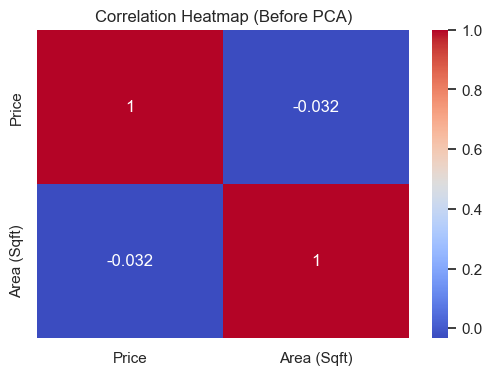

In [72]:
plt.figure(figsize=(6,4))
sns.heatmap(df_standardized[['Price','Area (Sqft)']].corr(), 
            annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Before PCA)")
plt.show()

The heatmap shows the correlation between the selected numerical features.

- The diagonal values are 1 because each feature is perfectly correlated with itself.
- The off-diagonal value shows the relationship between `Price` and `Area (Sqft)`.

If the value is close to 0, there is weak linear relationship between the two features.
If it is closer to 1 or -1, the relationship is stronger.

PCA is generally more beneficial when features are correlated.

## 6. Data Reduction – Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is a dimensionality reduction technique.

Instead of working directly with the original features, PCA creates new features called **principal components**.

These components:

- Are linear combinations of the original features
- Are uncorrelated with each other
- Capture variance in descending order (from most important to least)

The first principal component (PC1) captures the largest possible variance in the dataset.

The second principal component (PC2) captures the next largest variance, while being orthogonal (perpendicular) to PC1.

This allows us to reduce dimensionality while retaining most of the important information in the data.

### Visual Intuition

Imagine we have two features:

X1 = Price
X2 = Area (Sqft)

If we plot the data points, they may follow a diagonal pattern.
That means the two features are correlated and contain overlapping information.

Instead of keeping both X1 and X2 separately,
PCA finds the direction where the data varies the most.
That direction becomes **Principal Component 1 (PC1)**.

PC2 is perpendicular to PC1.
If most variation is along PC1, then PC1 alone captures most of the dataset's information.

In that case, we can reduce:

2 features -> 1 feature (PC1)

while keeping most of the variance.

In [73]:
from sklearn.decomposition import PCA

X = df_standardized[['Price', 'Area (Sqft)']]

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.51603119 0.48396881]


The `Explained Variance Ratio` indicates how much of the total information (variance) is captured by each principal component.

For example:
- If PC1 explains 85% of the variance, it means that one new feature already summarizes most of the dataset's information.
- If PC1 and PC2 together explain nearly 100%, then very little information is lost.

When most of the variance is captured by fewer components, dimensionality reduction is considered effective.

This helps simplify models, reduce computational cost, and sometimes improve generalization performance.

In [ ]:
# # In addition to the heatmap, we can visualize the relationship between two features using a scatter plot. 
# # A scatter plot allows us to observe whether the features exhibit a linear pattern, meaning whether they increase or decrease together in a consistent way.


# plt.figure(figsize=(6,4))
# plt.scatter(df_standardized['Price'], df_standardized['Area (Sqft)'])
# plt.xlabel("Price (Standardized)")
# plt.ylabel("Area (Sqft) (Standardized)")
# plt.title("Scatter Plot: Price vs Area (Sqft)")
# plt.show()

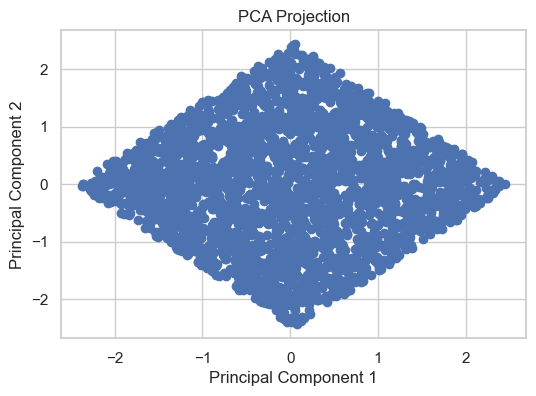

In [54]:
plt.figure(figsize=(6,4))
plt.scatter(principal_components[:,0], principal_components[:,1])
plt.title("PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

Each point in this plot represents one property listing.

The axes no longer represent the original features (`Price` and `Area (Sqft)`).
Instead:

- The horizontal axis represents Principal Component 1 (PC1).
- The vertical axis represents Principal Component 2 (PC2).

PC1 captures the direction of maximum variance in the data.
PC2 captures the second most important direction, perpendicular to PC1.

This projection allows us to visualize multi-feature data in a lower-dimensional space.

# Assignment

In this assignment, you will:
- **Task 1**
Identify data quality issues in the dataset.

- **Task 2**
Apply one missing value strategy and explain why.

- **Task 3**
Detect and handle outliers using IQR.

- **Task 4**
Normalize numerical features using both Min-Max and Z-score.

- **Task 5**
Apply PCA and interpret explained variance.


End of lab 4.